In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sales = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_sales_cleaned.csv")
df_inv = pd.read_csv(r"C:\Users\ASUS\Desktop\Desktop\Infotact Internship\Project 1 clean\Project-1-Omnichannel-retail-analysis-clean\cleaned_data\retail_inventory_cleaned.csv")

In [3]:
df_inv.isna().sum()
df_inv.info()

<class 'pandas.DataFrame'>
RangeIndex: 284755 entries, 0 to 284754
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   start_date                284755 non-null  str    
 1   end_date                  284755 non-null  str    
 2   stock_status              284755 non-null  str    
 3   supplier                  284755 non-null  str    
 4   product_no                284755 non-null  str    
 5   product_description       284755 non-null  str    
 6   product_division          284755 non-null  str    
 7   product_category          284755 non-null  str    
 8   product_subcategory       284755 non-null  str    
 9   product_segment           284755 non-null  str    
 10  store                     284755 non-null  str    
 11  store_type                284755 non-null  str    
 12  sales_channel             284755 non-null  str    
 13  qty_on_hand               284755 non-null  int64  
 14 

In [17]:
df_sales['transaction_date'] = pd.to_datetime( df_sales['transaction_date'], format='mixed', dayfirst=True)
df_inv['start_date'] = pd.to_datetime(df_inv['start_date'], dayfirst=True)
df_inv['end_date'] = pd.to_datetime(df_inv['end_date'], dayfirst=True, errors='coerce')

### Important Time Columns

In [19]:
df_sales['year'] = df_sales['transaction_date'].dt.year
df_sales['month'] = df_sales['transaction_date'].dt.month
df_sales['month_name'] = df_sales['transaction_date'].dt.month_name()

df_sales['day'] = df_sales['transaction_date'].dt.day

df_sales['weekday'] = df_sales['transaction_date'].dt.day_name()

df_sales['weekend_flag'] = np.where(
    df_sales['weekday'].isin(['Saturday', 'Sunday']),
    'Weekend',
    'Weekday'
)

### Creating Business KPIs

#### Store managers care about:

- Revenue
- Profit
- Fast moving products
- Store performance
- Weekend sales
- Inventory availability

In [21]:
#Create Profit Column
df_sales['profit'] = df_sales['sales_amount'] - df_sales['cogs']

#### Daily Revenue Trend

In [26]:
daily_sales = df_sales.groupby('transaction_date').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(daily_sales)

    transaction_date  sales_amount    profit  qty_sold
0         2025-01-06      22565.33  10892.08     244.0
1         2025-01-07      19023.62   8714.13     217.0
2         2025-01-08      55369.09  25282.07     624.0
3         2025-01-09      48997.97  23184.77     543.0
4         2025-01-10      17933.63   7299.19     202.0
..               ...           ...       ...       ...
321       2026-11-04      36806.51  16259.06     435.0
322       2026-12-01      10685.27   3945.82     143.0
323       2026-12-02      45015.85  20638.41     405.0
324       2026-12-03      29851.97  11273.57     385.0
325       2026-12-04      21345.70   9489.11     247.0

[326 rows x 4 columns]


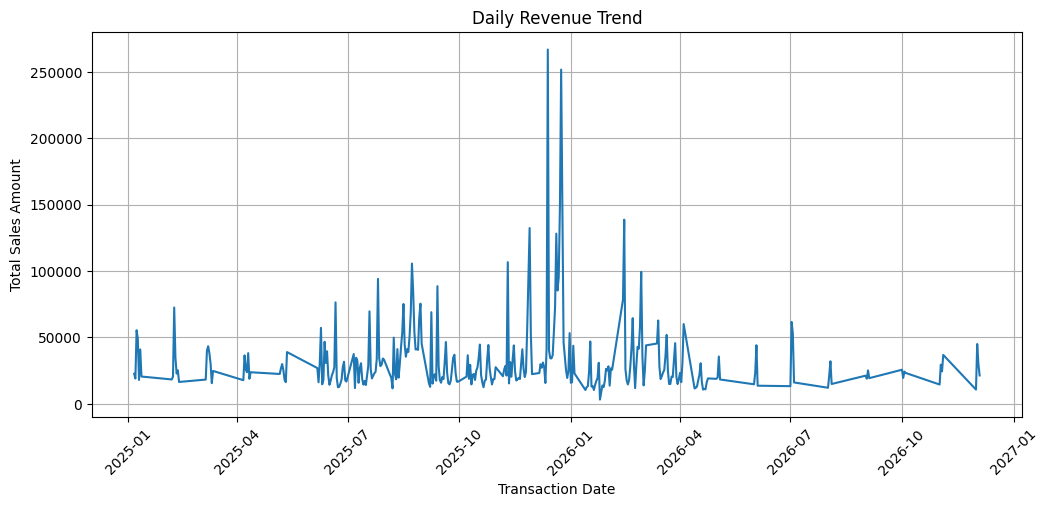

In [31]:
plt.figure(figsize=(12, 5))
plt.plot( daily_sales['transaction_date'], daily_sales['sales_amount'])
plt.title("Daily Revenue Trend")
plt.xlabel("Transaction Date")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Weekday vs Weekend Performance

In [40]:
weekend_analysis = df_sales.groupby('weekend_flag').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).reset_index()
print(weekend_analysis)

#Revenue Comparison
total = 6661650.38 + 3820459.87

weekday_percent = (6661650.38 / total) * 100
weekend_percent = (3820459.87 / total) * 100

print("Weekday % :", round(weekday_percent,2))
print("Weekend % :", round(weekend_percent,2))


  weekend_flag  sales_amount        profit  qty_sold
0      Weekday    6661650.38  2.928978e+06   75720.0
1      Weekend    3820459.87  1.705381e+06   41275.0
Weekday % : 63.55
Weekend % : 36.45


- The analysis shows that weekday sales contribute significantly more revenue than weekend sales. Approximately 63% of total revenue is generated during weekdays, indicating stronger customer purchasing activity on working days. Weekend sales still contribute a substantial portion of revenue but remain lower in comparison. This insight can help store managers optimize staffing, inventory allocation, and promotional campaigns based on customer traffic patterns.
---
#### Store manager can:

- Keep higher staff availability on weekdays
- Maintain more inventory during weekdays
- Run weekend promotions to increase traffic
- Identify if certain categories perform better on weekends

#### This can be misleading because:

- Weekdays = 5 days
- Weekend = 2 days

So naturally weekdays may have higher totals.

 so we calculate,  
#### Average sales per weekday vs per weekend day

In [45]:
daily_type_sales = df_sales.groupby(
    ['transaction_date', 'weekend_flag']
)['sales_amount'].sum().reset_index()

print("daily_type_sales : ")
print(daily_type_sales)
print()

avg_sales = daily_type_sales.groupby(
    'weekend_flag'
)['sales_amount'].mean().reset_index()

print('Average sales per weekday vs per weekend day ')
print(avg_sales)

daily_type_sales : 
    transaction_date weekend_flag  sales_amount
0         2025-01-06      Weekday      22565.33
1         2025-01-07      Weekday      19023.62
2         2025-01-08      Weekday      55369.09
3         2025-01-09      Weekday      48997.97
4         2025-01-10      Weekday      17933.63
..               ...          ...           ...
321       2026-11-04      Weekday      36806.51
322       2026-12-01      Weekday      10685.27
323       2026-12-02      Weekday      45015.85
324       2026-12-03      Weekday      29851.97
325       2026-12-04      Weekday      21345.70

[326 rows x 3 columns]

Average sales per weekday vs per weekend day 
  weekend_flag  sales_amount
0      Weekday  28714.010259
1      Weekend  40643.190106


#### so in summery : 
- Total weekday revenue > total weekend revenue
- Average revenue per weekend day > average revenue per weekday

#### This means:

- Customers spend more per day on weekends.

#### Product Category Trends

In [51]:
category_sales = df_sales.groupby('product_category').agg({
    'sales_amount':'sum',
    'profit':'sum',
    'qty_sold':'sum'
}).sort_values(by='sales_amount', ascending=False)

print(category_sales)

                                  sales_amount       profit  qty_sold
product_category                                                     
Scholar Footwear Retro Legend       1920958.56  905344.3400   12569.0
Scholar Footwear Trailblazer        1909759.99  927715.3700   20584.0
Femme Footwear Trailblazer          1238790.65  436689.0400   12325.0
Scholar Footwear Modern Legend      1062646.92  405024.2800   10731.0
Scholar Footwear Flight Classic      767298.33  354519.3300    8926.0
Scholar Footwear Court Casual        702385.90  281848.1800    9530.0
Scholar Footwear Boot Collection     660152.85  358274.6600    6049.0
Femme Footwear Court Casual          647820.37  240117.8001    7279.0
Femme Footwear Boot Collection       304630.62  154503.4900    2321.0
Femme Footwear Flight Classic        303495.26  140888.6700    2728.0
Femme Footwear Retro Legend          177667.32   85156.4200     849.0
Scholar Footwear Hardcourt           106883.73   41612.7700     702.0
Junior Apparel Cozy 